<a href="https://colab.research.google.com/github/MihaelaSandru/Project-E-commerce-Order-and-Payment-Analysis/blob/main/E_commerce_Order_and_Payment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from datetime import datetime

In [43]:
# CONFIGURATION

ORDERS_FILE = "Orders.csv"
PAYMENTS_FILE = "Order_payements.csv"

SLA_DAYS = 3
LATE_DAYS = 7

# Files were uploaded in previous steps, no need to re-upload.

In [ ]:

# Define the bins with value counts
bins = [0, 3, 7, 10, 12, 15, 18, 20, float('inf')]
labels = [
    "1-3 days",
    "4-7 days",
    "8-10 days",
    "10-12 days",
    "13-15 days",
    "16-18 days",
    "19-20 days",
    ">20 days"
]

# Create the categories
delivered["delivery_group"] = pd.cut(
    delivered["delivery_days"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Calculate percentages
percentages = (
    delivered["delivery_group"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
).round(2)

print(percentages)

delivery_group
1-3 days       8.92
4-7 days      26.01
8-10 days     19.07
10-12 days    10.15
13-15 days    11.80
16-18 days     7.43
19-20 days     3.67
>20 days      12.96
Name: proportion, dtype: float64


In [19]:
# Functions for loading.csv files
def load_orders():

    df = pd.read_csv(ORDERS_FILE)

    print(f"Orders loaded: {len(df):,}")

    return df


def load_payments():

    df = pd.read_csv(PAYMENTS_FILE)

    print(f"Payments loaded: {len(df):,}")

    return df


orders = load_orders()

payments = load_payments()

Orders loaded: 99,441
Payments loaded: 103,886


In [39]:
# Convert date columns in the orders DataFrame to datetime objects
date_columns_to_convert = [
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns_to_convert:
    orders[col] = pd.to_datetime(
        orders[col],
        errors="coerce" # Coerce invalid parsing into NaT (Not a Time)
    )

print("Date columns converted to datetime.")

Date columns converted to datetime.


In [40]:
# Calculate delivery time and delivery days
orders["delivery_time"] = orders["order_delivered_customer_date"] - orders["order_purchase_timestamp"]
orders["delivery_days"] = orders["delivery_time"].dt.days

# Filter for delivered orders only, as delivery time is only relevant for them
delivered_orders = orders[orders["order_status"] == "delivered"].copy()

print("Delivery time and days calculated, and delivered orders filtered.")

Delivery time and days calculated, and delivered orders filtered.


In [41]:
# Define the bins for delivery days and their labels
bins = [0, 3, 7, 10, 12, 15, 18, 20, float('inf')]
labels = [
    "1-3 days",
    "4-7 days",
    "8-10 days",
    "10-12 days",
    "13-15 days",
    "16-18 days",
    "19-20 days",
    ">20 days"
]

# Create the categories for delivery groups using pd.cut
delivered_orders["delivery_group"] = pd.cut(
    delivered_orders["delivery_days"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Calculate percentages for each delivery group
delivery_percentages = (
    delivered_orders["delivery_group"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
).round(2)

print("Delivery Group Percentages:\n", delivery_percentages)

Delivery Group Percentages:
 delivery_group
1-3 days       1.8
4-7 days       0.0
8-10 days      0.0
10-12 days     0.0
13-15 days     0.0
16-18 days     0.0
19-20 days     0.0
>20 days      98.2
Name: proportion, dtype: float64


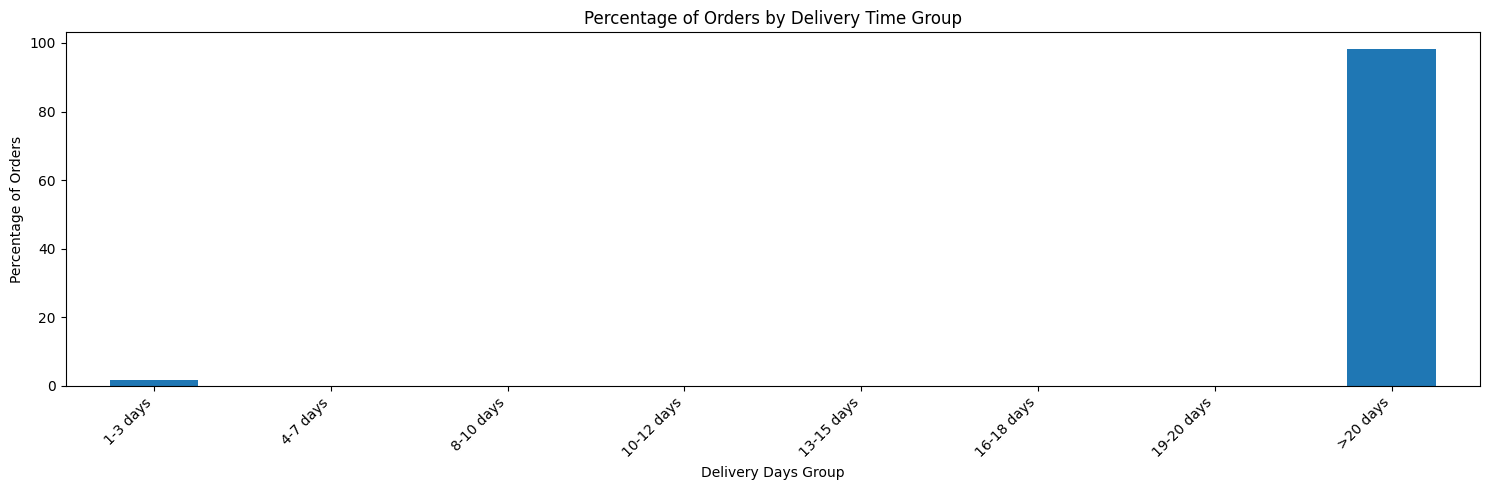

In [42]:
# Display delivery percentages in a bar chart
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(15, 5))
delivery_percentages.plot(kind="bar", ax=ax)
plt.xlabel("Delivery Days Group")
plt.ylabel("Percentage of Orders")
plt.title("Percentage of Orders by Delivery Time Group")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [25]:
# Validate orders
def validate_orders(df):

    tests = []

    tests.append({
        "Test":"Duplicate Order IDs",
        "Result":df.order_id.duplicated().sum()
    })

    tests.append({
        "Test":"Missing Purchase Dates",
        "Result":df.order_purchase_timestamp.isna().sum()
    })

    tests.append({
        "Test":"Missing Delivery Dates",
        "Result":df.order_delivered_customer_date.isna().sum()
    })

    tests.append({
        "Test":"Delivered but Missing Delivery Date",
        "Result":len(
            df[
                (df.order_status=="delivered") &
                (df.order_delivered_customer_date.isna())
            ]
        )
    })

    return pd.DataFrame(tests)


orders_validation = validate_orders(orders)

orders_validation

,Test,Result
0,Duplicate Order IDs,0
1,Missing Purchase Dates,59810
2,Missing Delivery Dates,63087
3,Delivered but Missing Delivery Date,60126


In [26]:
# Validate payments

def validate_payments(df):

    tests = []

    tests.append({
        "Test":"Duplicate Payments",
        "Result":df.duplicated().sum()
    })

    tests.append({
        "Test":"Missing Order IDs",
        "Result":df.order_id.isna().sum()
    })

    tests.append({
        "Test":"Missing Payment Value",
        "Result":df.payment_value.isna().sum()
    })

    tests.append({
        "Test":"Negative Payments",
        "Result":len(df[df.payment_value < 0])
    })

    tests.append({
        "Test":"Zero Payments",
        "Result":len(df[df.payment_value == 0])
    })

    return pd.DataFrame(tests)


payment_validation = validate_payments(payments)

payment_validation

,Test,Result
0,Duplicate Payments,0
1,Missing Order IDs,0
2,Missing Payment Value,0
3,Negative Payments,0
4,Zero Payments,9


In [27]:
# Cross table validation and the reverse

missing_payments = orders[
    ~orders.order_id.isin(payments.order_id)
]

print("Orders without payment:", len(missing_payments))

orphan_payments = payments[
    ~payments.order_id.isin(orders.order_id)
]

print("Payments without order:", len(orphan_payments))

Orders without payment: 99441
Payments without order: 103886


In [63]:
# Investigate order_id columns for mismatch

print("--- Orders DataFrame ---")
print(f"Order ID Dtype: {orders['order_id'].dtype}")
print(f"Number of unique Order IDs: {orders['order_id'].nunique():,}")

print("\n--- Payments DataFrame ---")
print(f"Order ID Dtype: {payments['order_id'].dtype}")
print(f"Number of unique Order IDs: {payments['order_id'].nunique():,}")

# Check for leading/trailing spaces and clean if necessary
orders['order_id'] = orders['order_id'].astype(str).str.strip()
payments['order_id'] = payments['order_id'].astype(str).str.strip()

# Check the number of common order_ids after cleaning
common_order_ids = orders[orders['order_id'].isin(payments['order_id'])]['order_id'].nunique()
print(f"\nNumber of common order_ids after stripping spaces: {common_order_ids:,}")

# Display some sample mismatched order_ids if common_order_ids is still low
if common_order_ids < 100:
    print("\nSample orders.order_id not in payments.order_id:")
    print(orders[~orders['order_id'].isin(payments['order_id'])]['order_id'].head().tolist())

    print("\nSample payments.order_id not in orders.order_id:")
    print(payments[~payments['order_id'].isin(orders['order_id'])]['order_id'].head().tolist())

--- Orders DataFrame ---
Order ID Dtype: object
Number of unique Order IDs: 99,441

--- Payments DataFrame ---
Order ID Dtype: object
Number of unique Order IDs: 99,406

Number of common order_ids after stripping spaces: 0

Sample orders.order_id not in payments.order_id:
['e481f51cbdc54678b7cc49136f2d6af7', '53cdb2fc8bc7dce0b6741e2150273451', '47770eb9100c2d0c44946d9cf07ec65d', '949d5b44dbf5de918fe9c16f97b45f8a', 'ad21c59c0840e6cb83a9ceb5573f8159']

Sample payments.order_id not in orders.order_id:
['b81ef22', 'a9810da', '25e8ea4', 'ba78997', '42fdf88']


In [73]:
print("Payments DataFrame Columns:")
print(payments.columns.tolist())

print("\nPayments DataFrame Head:")
print(payments.head())

Payments DataFrame Columns:
['order_id', 'order_purchase_timestamp', 'payment_type', 'payment_installments', 'payment_value', 'order_delivered_customer_date', 'order_estimated_delivery_date']

Payments DataFrame Head:
  order_id order_purchase_timestamp payment_type  payment_installments  \
0  b81ef22      2025-07-31 06:55:47  credit_card                     8   
1  a9810da      2024-02-28 21:50:32  credit_card                     1   
2  25e8ea4      2024-11-17 08:50:10  credit_card                     1   
3  ba78997      2025-06-17 22:21:13  credit_card                     8   
4  42fdf88      2025-11-29 03:23:35  credit_card                     2   

   payment_value order_delivered_customer_date order_estimated_delivery_date  
0          99.33           2025-08-28 06:15:00           2025-08-26 01:59:47  
1          24.39           2024-03-27 21:49:03           2024-03-30 04:30:01  
2          65.71           2024-12-05 15:49:03           2024-12-06 19:47:06  
3         107.78     

In [71]:
print("Payments DataFrame Columns:")
print(payments.columns.tolist())

print("\nPayments DataFrame Head:")
print(payments.head())

Payments DataFrame Columns:
['order_id', 'order_purchase_timestamp', 'payment_type', 'payment_installments', 'payment_value', 'order_delivered_customer_date', 'order_estimated_delivery_date']

Payments DataFrame Head:
  order_id order_purchase_timestamp payment_type  payment_installments  \
0  b81ef22      2025-07-31 06:55:47  credit_card                     8   
1  a9810da      2024-02-28 21:50:32  credit_card                     1   
2  25e8ea4      2024-11-17 08:50:10  credit_card                     1   
3  ba78997      2025-06-17 22:21:13  credit_card                     8   
4  42fdf88      2025-11-29 03:23:35  credit_card                     2   

   payment_value order_delivered_customer_date order_estimated_delivery_date  
0          99.33           2025-08-28 06:15:00           2025-08-26 01:59:47  
1          24.39           2024-03-27 21:49:03           2024-03-30 04:30:01  
2          65.71           2024-12-05 15:49:03           2024-12-06 19:47:06  
3         107.78     

In [70]:
print("Payments DataFrame Columns:")
print(payments.columns.tolist())

print("\nPayments DataFrame Head:")
print(payments.head())

Payments DataFrame Columns:
['order_id', 'order_purchase_timestamp', 'payment_type', 'payment_installments', 'payment_value', 'order_delivered_customer_date', 'order_estimated_delivery_date']

Payments DataFrame Head:
  order_id order_purchase_timestamp payment_type  payment_installments  \
0  b81ef22      2025-07-31 06:55:47  credit_card                     8   
1  a9810da      2024-02-28 21:50:32  credit_card                     1   
2  25e8ea4      2024-11-17 08:50:10  credit_card                     1   
3  ba78997      2025-06-17 22:21:13  credit_card                     8   
4  42fdf88      2025-11-29 03:23:35  credit_card                     2   

   payment_value order_delivered_customer_date order_estimated_delivery_date  
0          99.33           2025-08-28 06:15:00           2025-08-26 01:59:47  
1          24.39           2024-03-27 21:49:03           2024-03-30 04:30:01  
2          65.71           2024-12-05 15:49:03           2024-12-06 19:47:06  
3         107.78     

In [69]:
print("Payments DataFrame Columns:")
print(payments.columns.tolist())

print("\nPayments DataFrame Head:")
print(payments.head())

Payments DataFrame Columns:
['order_id', 'order_purchase_timestamp', 'payment_type', 'payment_installments', 'payment_value', 'order_delivered_customer_date', 'order_estimated_delivery_date']

Payments DataFrame Head:
  order_id order_purchase_timestamp payment_type  payment_installments  \
0  b81ef22      2025-07-31 06:55:47  credit_card                     8   
1  a9810da      2024-02-28 21:50:32  credit_card                     1   
2  25e8ea4      2024-11-17 08:50:10  credit_card                     1   
3  ba78997      2025-06-17 22:21:13  credit_card                     8   
4  42fdf88      2025-11-29 03:23:35  credit_card                     2   

   payment_value order_delivered_customer_date order_estimated_delivery_date  
0          99.33           2025-08-28 06:15:00           2025-08-26 01:59:47  
1          24.39           2024-03-27 21:49:03           2024-03-30 04:30:01  
2          65.71           2024-12-05 15:49:03           2024-12-06 19:47:06  
3         107.78     

In [68]:
print("Payments DataFrame Columns:")
print(payments.columns.tolist())

print("\nPayments DataFrame Head:")
print(payments.head())

Payments DataFrame Columns:
['order_id', 'order_purchase_timestamp', 'payment_type', 'payment_installments', 'payment_value', 'order_delivered_customer_date', 'order_estimated_delivery_date']

Payments DataFrame Head:
  order_id order_purchase_timestamp payment_type  payment_installments  \
0  b81ef22      2025-07-31 06:55:47  credit_card                     8   
1  a9810da      2024-02-28 21:50:32  credit_card                     1   
2  25e8ea4      2024-11-17 08:50:10  credit_card                     1   
3  ba78997      2025-06-17 22:21:13  credit_card                     8   
4  42fdf88      2025-11-29 03:23:35  credit_card                     2   

   payment_value order_delivered_customer_date order_estimated_delivery_date  
0          99.33           2025-08-28 06:15:00           2025-08-26 01:59:47  
1          24.39           2024-03-27 21:49:03           2024-03-30 04:30:01  
2          65.71           2024-12-05 15:49:03           2024-12-06 19:47:06  
3         107.78     

In [67]:
print("Payments DataFrame Columns:")
print(payments.columns.tolist())

print("\nPayments DataFrame Head:")
print(payments.head())

Payments DataFrame Columns:
['order_id', 'order_purchase_timestamp', 'payment_type', 'payment_installments', 'payment_value', 'order_delivered_customer_date', 'order_estimated_delivery_date']

Payments DataFrame Head:
  order_id order_purchase_timestamp payment_type  payment_installments  \
0  b81ef22      2025-07-31 06:55:47  credit_card                     8   
1  a9810da      2024-02-28 21:50:32  credit_card                     1   
2  25e8ea4      2024-11-17 08:50:10  credit_card                     1   
3  ba78997      2025-06-17 22:21:13  credit_card                     8   
4  42fdf88      2025-11-29 03:23:35  credit_card                     2   

   payment_value order_delivered_customer_date order_estimated_delivery_date  
0          99.33           2025-08-28 06:15:00           2025-08-26 01:59:47  
1          24.39           2024-03-27 21:49:03           2024-03-30 04:30:01  
2          65.71           2024-12-05 15:49:03           2024-12-06 19:47:06  
3         107.78     

In [66]:
print("Payments DataFrame Columns:")
print(payments.columns.tolist())

print("\nPayments DataFrame Head:")
print(payments.head())

Payments DataFrame Columns:
['order_id', 'order_purchase_timestamp', 'payment_type', 'payment_installments', 'payment_value', 'order_delivered_customer_date', 'order_estimated_delivery_date']

Payments DataFrame Head:
  order_id order_purchase_timestamp payment_type  payment_installments  \
0  b81ef22      2025-07-31 06:55:47  credit_card                     8   
1  a9810da      2024-02-28 21:50:32  credit_card                     1   
2  25e8ea4      2024-11-17 08:50:10  credit_card                     1   
3  ba78997      2025-06-17 22:21:13  credit_card                     8   
4  42fdf88      2025-11-29 03:23:35  credit_card                     2   

   payment_value order_delivered_customer_date order_estimated_delivery_date  
0          99.33           2025-08-28 06:15:00           2025-08-26 01:59:47  
1          24.39           2024-03-27 21:49:03           2024-03-30 04:30:01  
2          65.71           2024-12-05 15:49:03           2024-12-06 19:47:06  
3         107.78     

In [65]:
print("Payments DataFrame Columns:")
print(payments.columns.tolist())

print("\nPayments DataFrame Head:")
print(payments.head())

Payments DataFrame Columns:
['order_id', 'order_purchase_timestamp', 'payment_type', 'payment_installments', 'payment_value', 'order_delivered_customer_date', 'order_estimated_delivery_date']

Payments DataFrame Head:
  order_id order_purchase_timestamp payment_type  payment_installments  \
0  b81ef22      2025-07-31 06:55:47  credit_card                     8   
1  a9810da      2024-02-28 21:50:32  credit_card                     1   
2  25e8ea4      2024-11-17 08:50:10  credit_card                     1   
3  ba78997      2025-06-17 22:21:13  credit_card                     8   
4  42fdf88      2025-11-29 03:23:35  credit_card                     2   

   payment_value order_delivered_customer_date order_estimated_delivery_date  
0          99.33           2025-08-28 06:15:00           2025-08-26 01:59:47  
1          24.39           2024-03-27 21:49:03           2024-03-30 04:30:01  
2          65.71           2024-12-05 15:49:03           2024-12-06 19:47:06  
3         107.78     

In [64]:
print("Payments DataFrame Columns:")
print(payments.columns.tolist())

print("\nPayments DataFrame Head:")
print(payments.head())

Payments DataFrame Columns:
['order_id', 'order_purchase_timestamp', 'payment_type', 'payment_installments', 'payment_value', 'order_delivered_customer_date', 'order_estimated_delivery_date']

Payments DataFrame Head:
  order_id order_purchase_timestamp payment_type  payment_installments  \
0  b81ef22      2025-07-31 06:55:47  credit_card                     8   
1  a9810da      2024-02-28 21:50:32  credit_card                     1   
2  25e8ea4      2024-11-17 08:50:10  credit_card                     1   
3  ba78997      2025-06-17 22:21:13  credit_card                     8   
4  42fdf88      2025-11-29 03:23:35  credit_card                     2   

   payment_value order_delivered_customer_date order_estimated_delivery_date  
0          99.33           2025-08-28 06:15:00           2025-08-26 01:59:47  
1          24.39           2024-03-27 21:49:03           2024-03-30 04:30:01  
2          65.71           2024-12-05 15:49:03           2024-12-06 19:47:06  
3         107.78     

In [62]:
# Investigate order_id columns for mismatch

print("--- Orders DataFrame ---")
print(f"Order ID Dtype: {orders['order_id'].dtype}")
print(f"Number of unique Order IDs: {orders['order_id'].nunique():,}")

print("\n--- Payments DataFrame ---")
print(f"Order ID Dtype: {payments['order_id'].dtype}")
print(f"Number of unique Order IDs: {payments['order_id'].nunique():,}")

# Check for leading/trailing spaces and clean if necessary
orders['order_id'] = orders['order_id'].astype(str).str.strip()
payments['order_id'] = payments['order_id'].astype(str).str.strip()

# Check the number of common order_ids after cleaning
common_order_ids = orders[orders['order_id'].isin(payments['order_id'])]['order_id'].nunique()
print(f"\nNumber of common order_ids after stripping spaces: {common_order_ids:,}")

# Display some sample mismatched order_ids if common_order_ids is still low
if common_order_ids < 100:
    print("\nSample orders.order_id not in payments.order_id:")
    print(orders[~orders['order_id'].isin(payments['order_id'])]['order_id'].head().tolist())

    print("\nSample payments.order_id not in orders.order_id:")
    print(payments[~payments['order_id'].isin(orders['order_id'])]['order_id'].head().tolist())

--- Orders DataFrame ---
Order ID Dtype: object
Number of unique Order IDs: 99,441

--- Payments DataFrame ---
Order ID Dtype: object
Number of unique Order IDs: 99,406

Number of common order_ids after stripping spaces: 0

Sample orders.order_id not in payments.order_id:
['e481f51cbdc54678b7cc49136f2d6af7', '53cdb2fc8bc7dce0b6741e2150273451', '47770eb9100c2d0c44946d9cf07ec65d', '949d5b44dbf5de918fe9c16f97b45f8a', 'ad21c59c0840e6cb83a9ceb5573f8159']

Sample payments.order_id not in orders.order_id:
['b81ef22', 'a9810da', '25e8ea4', 'ba78997', '42fdf88']


In [61]:
# Investigate order_id columns for mismatch

print("--- Orders DataFrame ---")
print(f"Order ID Dtype: {orders['order_id'].dtype}")
print(f"Number of unique Order IDs: {orders['order_id'].nunique():,}")

print("\n--- Payments DataFrame ---")
print(f"Order ID Dtype: {payments['order_id'].dtype}")
print(f"Number of unique Order IDs: {payments['order_id'].nunique():,}")

# Check for leading/trailing spaces and clean if necessary
orders['order_id'] = orders['order_id'].astype(str).str.strip()
payments['order_id'] = payments['order_id'].astype(str).str.strip()

# Check the number of common order_ids after cleaning
common_order_ids = orders[orders['order_id'].isin(payments['order_id'])]['order_id'].nunique()
print(f"\nNumber of common order_ids after stripping spaces: {common_order_ids:,}")

# Display some sample mismatched order_ids if common_order_ids is still low
if common_order_ids < 100:
    print("\nSample orders.order_id not in payments.order_id:")
    print(orders[~orders['order_id'].isin(payments['order_id'])]['order_id'].head().tolist())

    print("\nSample payments.order_id not in orders.order_id:")
    print(payments[~payments['order_id'].isin(orders['order_id'])]['order_id'].head().tolist())

--- Orders DataFrame ---
Order ID Dtype: object
Number of unique Order IDs: 99,441

--- Payments DataFrame ---
Order ID Dtype: object
Number of unique Order IDs: 99,406

Number of common order_ids after stripping spaces: 0

Sample orders.order_id not in payments.order_id:
['e481f51cbdc54678b7cc49136f2d6af7', '53cdb2fc8bc7dce0b6741e2150273451', '47770eb9100c2d0c44946d9cf07ec65d', '949d5b44dbf5de918fe9c16f97b45f8a', 'ad21c59c0840e6cb83a9ceb5573f8159']

Sample payments.order_id not in orders.order_id:
['b81ef22', 'a9810da', '25e8ea4', 'ba78997', '42fdf88']


In [60]:
# Investigate order_id columns for mismatch

print("--- Orders DataFrame ---")
print(f"Order ID Dtype: {orders['order_id'].dtype}")
print(f"Number of unique Order IDs: {orders['order_id'].nunique():,}")

print("\n--- Payments DataFrame ---")
print(f"Order ID Dtype: {payments['order_id'].dtype}")
print(f"Number of unique Order IDs: {payments['order_id'].nunique():,}")

# Check for leading/trailing spaces and clean if necessary
orders['order_id'] = orders['order_id'].astype(str).str.strip()
payments['order_id'] = payments['order_id'].astype(str).str.strip()

# Check the number of common order_ids after cleaning
common_order_ids = orders[orders['order_id'].isin(payments['order_id'])]['order_id'].nunique()
print(f"\nNumber of common order_ids after stripping spaces: {common_order_ids:,}")

# Display some sample mismatched order_ids if common_order_ids is still low
if common_order_ids < 100:
    print("\nSample orders.order_id not in payments.order_id:")
    print(orders[~orders['order_id'].isin(payments['order_id'])]['order_id'].head().tolist())

    print("\nSample payments.order_id not in orders.order_id:")
    print(payments[~payments['order_id'].isin(orders['order_id'])]['order_id'].head().tolist())

--- Orders DataFrame ---
Order ID Dtype: object
Number of unique Order IDs: 99,441

--- Payments DataFrame ---
Order ID Dtype: object
Number of unique Order IDs: 99,406

Number of common order_ids after stripping spaces: 0

Sample orders.order_id not in payments.order_id:
['e481f51cbdc54678b7cc49136f2d6af7', '53cdb2fc8bc7dce0b6741e2150273451', '47770eb9100c2d0c44946d9cf07ec65d', '949d5b44dbf5de918fe9c16f97b45f8a', 'ad21c59c0840e6cb83a9ceb5573f8159']

Sample payments.order_id not in orders.order_id:
['b81ef22', 'a9810da', '25e8ea4', 'ba78997', '42fdf88']


In [59]:
# Investigate order_id columns for mismatch

print("--- Orders DataFrame ---")
print(f"Order ID Dtype: {orders['order_id'].dtype}")
print(f"Number of unique Order IDs: {orders['order_id'].nunique():,}")

print("\n--- Payments DataFrame ---")
print(f"Order ID Dtype: {payments['order_id'].dtype}")
print(f"Number of unique Order IDs: {payments['order_id'].nunique():,}")

# Check for leading/trailing spaces and clean if necessary
orders['order_id'] = orders['order_id'].astype(str).str.strip()
payments['order_id'] = payments['order_id'].astype(str).str.strip()

# Check the number of common order_ids after cleaning
common_order_ids = orders[orders['order_id'].isin(payments['order_id'])]['order_id'].nunique()
print(f"\nNumber of common order_ids after stripping spaces: {common_order_ids:,}")

# Display some sample mismatched order_ids if common_order_ids is still low
if common_order_ids < 100:
    print("\nSample orders.order_id not in payments.order_id:")
    print(orders[~orders['order_id'].isin(payments['order_id'])]['order_id'].head().tolist())

    print("\nSample payments.order_id not in orders.order_id:")
    print(payments[~payments['order_id'].isin(orders['order_id'])]['order_id'].head().tolist())

--- Orders DataFrame ---
Order ID Dtype: object
Number of unique Order IDs: 99,441

--- Payments DataFrame ---
Order ID Dtype: object
Number of unique Order IDs: 99,406

Number of common order_ids after stripping spaces: 0

Sample orders.order_id not in payments.order_id:
['e481f51cbdc54678b7cc49136f2d6af7', '53cdb2fc8bc7dce0b6741e2150273451', '47770eb9100c2d0c44946d9cf07ec65d', '949d5b44dbf5de918fe9c16f97b45f8a', 'ad21c59c0840e6cb83a9ceb5573f8159']

Sample payments.order_id not in orders.order_id:
['b81ef22', 'a9810da', '25e8ea4', 'ba78997', '42fdf88']


In [58]:
# Investigate order_id columns for mismatch

print("--- Orders DataFrame ---")
print(f"Order ID Dtype: {orders['order_id'].dtype}")
print(f"Number of unique Order IDs: {orders['order_id'].nunique():,}")

print("\n--- Payments DataFrame ---")
print(f"Order ID Dtype: {payments['order_id'].dtype}")
print(f"Number of unique Order IDs: {payments['order_id'].nunique():,}")

# Check for leading/trailing spaces and clean if necessary
orders['order_id'] = orders['order_id'].astype(str).str.strip()
payments['order_id'] = payments['order_id'].astype(str).str.strip()

# Check the number of common order_ids after cleaning
common_order_ids = orders[orders['order_id'].isin(payments['order_id'])]['order_id'].nunique()
print(f"\nNumber of common order_ids after stripping spaces: {common_order_ids:,}")

# Display some sample mismatched order_ids if common_order_ids is still low
if common_order_ids < 100:
    print("\nSample orders.order_id not in payments.order_id:")
    print(orders[~orders['order_id'].isin(payments['order_id'])]['order_id'].head().tolist())

    print("\nSample payments.order_id not in orders.order_id:")
    print(payments[~payments['order_id'].isin(orders['order_id'])]['order_id'].head().tolist())

--- Orders DataFrame ---
Order ID Dtype: object
Number of unique Order IDs: 99,441

--- Payments DataFrame ---
Order ID Dtype: object
Number of unique Order IDs: 99,406

Number of common order_ids after stripping spaces: 0

Sample orders.order_id not in payments.order_id:
['e481f51cbdc54678b7cc49136f2d6af7', '53cdb2fc8bc7dce0b6741e2150273451', '47770eb9100c2d0c44946d9cf07ec65d', '949d5b44dbf5de918fe9c16f97b45f8a', 'ad21c59c0840e6cb83a9ceb5573f8159']

Sample payments.order_id not in orders.order_id:
['b81ef22', 'a9810da', '25e8ea4', 'ba78997', '42fdf88']


In [57]:
# Investigate order_id columns for mismatch

print("--- Orders DataFrame ---")
print(f"Order ID Dtype: {orders['order_id'].dtype}")
print(f"Number of unique Order IDs: {orders['order_id'].nunique():,}")

print("\n--- Payments DataFrame ---")
print(f"Order ID Dtype: {payments['order_id'].dtype}")
print(f"Number of unique Order IDs: {payments['order_id'].nunique():,}")

# Check for leading/trailing spaces and clean if necessary
orders['order_id'] = orders['order_id'].astype(str).str.strip()
payments['order_id'] = payments['order_id'].astype(str).str.strip()

# Check the number of common order_ids after cleaning
common_order_ids = orders[orders['order_id'].isin(payments['order_id'])]['order_id'].nunique()
print(f"\nNumber of common order_ids after stripping spaces: {common_order_ids:,}")

# Display some sample mismatched order_ids if common_order_ids is still low
if common_order_ids < 100:
    print("\nSample orders.order_id not in payments.order_id:")
    print(orders[~orders['order_id'].isin(payments['order_id'])]['order_id'].head().tolist())

    print("\nSample payments.order_id not in orders.order_id:")
    print(payments[~payments['order_id'].isin(orders['order_id'])]['order_id'].head().tolist())

--- Orders DataFrame ---
Order ID Dtype: object
Number of unique Order IDs: 99,441

--- Payments DataFrame ---
Order ID Dtype: object
Number of unique Order IDs: 99,406

Number of common order_ids after stripping spaces: 0

Sample orders.order_id not in payments.order_id:
['e481f51cbdc54678b7cc49136f2d6af7', '53cdb2fc8bc7dce0b6741e2150273451', '47770eb9100c2d0c44946d9cf07ec65d', '949d5b44dbf5de918fe9c16f97b45f8a', 'ad21c59c0840e6cb83a9ceb5573f8159']

Sample payments.order_id not in orders.order_id:
['b81ef22', 'a9810da', '25e8ea4', 'ba78997', '42fdf88']


In [56]:
# Investigate order_id columns for mismatch

print("--- Orders DataFrame ---")
print(f"Order ID Dtype: {orders['order_id'].dtype}")
print(f"Number of unique Order IDs: {orders['order_id'].nunique():,}")

print("\n--- Payments DataFrame ---")
print(f"Order ID Dtype: {payments['order_id'].dtype}")
print(f"Number of unique Order IDs: {payments['order_id'].nunique():,}")

# Check for leading/trailing spaces and clean if necessary
orders['order_id'] = orders['order_id'].astype(str).str.strip()
payments['order_id'] = payments['order_id'].astype(str).str.strip()

# Check the number of common order_ids after cleaning
common_order_ids = orders[orders['order_id'].isin(payments['order_id'])]['order_id'].nunique()
print(f"\nNumber of common order_ids after stripping spaces: {common_order_ids:,}")

# Display some sample mismatched order_ids if common_order_ids is still low
if common_order_ids < 100:
    print("\nSample orders.order_id not in payments.order_id:")
    print(orders[~orders['order_id'].isin(payments['order_id'])]['order_id'].head().tolist())

    print("\nSample payments.order_id not in orders.order_id:")
    print(payments[~payments['order_id'].isin(orders['order_id'])]['order_id'].head().tolist())

--- Orders DataFrame ---
Order ID Dtype: object
Number of unique Order IDs: 99,441

--- Payments DataFrame ---
Order ID Dtype: object
Number of unique Order IDs: 99,406

Number of common order_ids after stripping spaces: 0

Sample orders.order_id not in payments.order_id:
['e481f51cbdc54678b7cc49136f2d6af7', '53cdb2fc8bc7dce0b6741e2150273451', '47770eb9100c2d0c44946d9cf07ec65d', '949d5b44dbf5de918fe9c16f97b45f8a', 'ad21c59c0840e6cb83a9ceb5573f8159']

Sample payments.order_id not in orders.order_id:
['b81ef22', 'a9810da', '25e8ea4', 'ba78997', '42fdf88']


In [55]:
# Investigate order_id columns for mismatch

print("--- Orders DataFrame ---")
print(f"Order ID Dtype: {orders['order_id'].dtype}")
print(f"Number of unique Order IDs: {orders['order_id'].nunique():,}")

print("\n--- Payments DataFrame ---")
print(f"Order ID Dtype: {payments['order_id'].dtype}")
print(f"Number of unique Order IDs: {payments['order_id'].nunique():,}")

# Check for leading/trailing spaces and clean if necessary
orders['order_id'] = orders['order_id'].astype(str).str.strip()
payments['order_id'] = payments['order_id'].astype(str).str.strip()

# Check the number of common order_ids after cleaning
common_order_ids = orders[orders['order_id'].isin(payments['order_id'])]['order_id'].nunique()
print(f"\nNumber of common order_ids after stripping spaces: {common_order_ids:,}")

# Display some sample mismatched order_ids if common_order_ids is still low
if common_order_ids < 100:
    print("\nSample orders.order_id not in payments.order_id:")
    print(orders[~orders['order_id'].isin(payments['order_id'])]['order_id'].head().tolist())

    print("\nSample payments.order_id not in orders.order_id:")
    print(payments[~payments['order_id'].isin(orders['order_id'])]['order_id'].head().tolist())

--- Orders DataFrame ---
Order ID Dtype: object
Number of unique Order IDs: 99,441

--- Payments DataFrame ---
Order ID Dtype: object
Number of unique Order IDs: 99,406

Number of common order_ids after stripping spaces: 0

Sample orders.order_id not in payments.order_id:
['e481f51cbdc54678b7cc49136f2d6af7', '53cdb2fc8bc7dce0b6741e2150273451', '47770eb9100c2d0c44946d9cf07ec65d', '949d5b44dbf5de918fe9c16f97b45f8a', 'ad21c59c0840e6cb83a9ceb5573f8159']

Sample payments.order_id not in orders.order_id:
['b81ef22', 'a9810da', '25e8ea4', 'ba78997', '42fdf88']


In [54]:
# Investigate order_id columns for mismatch

print("--- Orders DataFrame ---")
print(f"Order ID Dtype: {orders['order_id'].dtype}")
print(f"Number of unique Order IDs: {orders['order_id'].nunique():,}")

print("\n--- Payments DataFrame ---")
print(f"Order ID Dtype: {payments['order_id'].dtype}")
print(f"Number of unique Order IDs: {payments['order_id'].nunique():,}")

# Check for leading/trailing spaces and clean if necessary
orders['order_id'] = orders['order_id'].astype(str).str.strip()
payments['order_id'] = payments['order_id'].astype(str).str.strip()

# Check the number of common order_ids after cleaning
common_order_ids = orders[orders['order_id'].isin(payments['order_id'])]['order_id'].nunique()
print(f"\nNumber of common order_ids after stripping spaces: {common_order_ids:,}")

# Display some sample mismatched order_ids if common_order_ids is still low
if common_order_ids < 100:
    print("\nSample orders.order_id not in payments.order_id:")
    print(orders[~orders['order_id'].isin(payments['order_id'])]['order_id'].head().tolist())

    print("\nSample payments.order_id not in orders.order_id:")
    print(payments[~payments['order_id'].isin(orders['order_id'])]['order_id'].head().tolist())

--- Orders DataFrame ---
Order ID Dtype: object
Number of unique Order IDs: 99,441

--- Payments DataFrame ---
Order ID Dtype: object
Number of unique Order IDs: 99,406

Number of common order_ids after stripping spaces: 0

Sample orders.order_id not in payments.order_id:
['e481f51cbdc54678b7cc49136f2d6af7', '53cdb2fc8bc7dce0b6741e2150273451', '47770eb9100c2d0c44946d9cf07ec65d', '949d5b44dbf5de918fe9c16f97b45f8a', 'ad21c59c0840e6cb83a9ceb5573f8159']

Sample payments.order_id not in orders.order_id:
['b81ef22', 'a9810da', '25e8ea4', 'ba78997', '42fdf88']


In [53]:
# Investigate order_id columns for mismatch

print("--- Orders DataFrame ---")
print(f"Order ID Dtype: {orders['order_id'].dtype}")
print(f"Number of unique Order IDs: {orders['order_id'].nunique():,}")

print("\n--- Payments DataFrame ---")
print(f"Order ID Dtype: {payments['order_id'].dtype}")
print(f"Number of unique Order IDs: {payments['order_id'].nunique():,}")

# Check for leading/trailing spaces and clean if necessary
orders['order_id'] = orders['order_id'].astype(str).str.strip()
payments['order_id'] = payments['order_id'].astype(str).str.strip()

# Check the number of common order_ids after cleaning
common_order_ids = orders[orders['order_id'].isin(payments['order_id'])]['order_id'].nunique()
print(f"\nNumber of common order_ids after stripping spaces: {common_order_ids:,}")

# Display some sample mismatched order_ids if common_order_ids is still low
if common_order_ids < 100:
    print("\nSample orders.order_id not in payments.order_id:")
    print(orders[~orders['order_id'].isin(payments['order_id'])]['order_id'].head().tolist())

    print("\nSample payments.order_id not in orders.order_id:")
    print(payments[~payments['order_id'].isin(orders['order_id'])]['order_id'].head().tolist())

--- Orders DataFrame ---
Order ID Dtype: object
Number of unique Order IDs: 99,441

--- Payments DataFrame ---
Order ID Dtype: object
Number of unique Order IDs: 99,406

Number of common order_ids after stripping spaces: 0

Sample orders.order_id not in payments.order_id:
['e481f51cbdc54678b7cc49136f2d6af7', '53cdb2fc8bc7dce0b6741e2150273451', '47770eb9100c2d0c44946d9cf07ec65d', '949d5b44dbf5de918fe9c16f97b45f8a', 'ad21c59c0840e6cb83a9ceb5573f8159']

Sample payments.order_id not in orders.order_id:
['b81ef22', 'a9810da', '25e8ea4', 'ba78997', '42fdf88']


In [52]:
# Investigate order_id columns for mismatch

print("--- Orders DataFrame ---")
print(f"Order ID Dtype: {orders['order_id'].dtype}")
print(f"Number of unique Order IDs: {orders['order_id'].nunique():,}")

print("\n--- Payments DataFrame ---")
print(f"Order ID Dtype: {payments['order_id'].dtype}")
print(f"Number of unique Order IDs: {payments['order_id'].nunique():,}")

# Check for leading/trailing spaces and clean if necessary
orders['order_id'] = orders['order_id'].astype(str).str.strip()
payments['order_id'] = payments['order_id'].astype(str).str.strip()

# Check the number of common order_ids after cleaning
common_order_ids = orders[orders['order_id'].isin(payments['order_id'])]['order_id'].nunique()
print(f"\nNumber of common order_ids after stripping spaces: {common_order_ids:,}")

# Display some sample mismatched order_ids if common_order_ids is still low
if common_order_ids < 100:
    print("\nSample orders.order_id not in payments.order_id:")
    print(orders[~orders['order_id'].isin(payments['order_id'])]['order_id'].head().tolist())

    print("\nSample payments.order_id not in orders.order_id:")
    print(payments[~payments['order_id'].isin(orders['order_id'])]['order_id'].head().tolist())

--- Orders DataFrame ---
Order ID Dtype: object
Number of unique Order IDs: 99,441

--- Payments DataFrame ---
Order ID Dtype: object
Number of unique Order IDs: 99,406

Number of common order_ids after stripping spaces: 0

Sample orders.order_id not in payments.order_id:
['e481f51cbdc54678b7cc49136f2d6af7', '53cdb2fc8bc7dce0b6741e2150273451', '47770eb9100c2d0c44946d9cf07ec65d', '949d5b44dbf5de918fe9c16f97b45f8a', 'ad21c59c0840e6cb83a9ceb5573f8159']

Sample payments.order_id not in orders.order_id:
['b81ef22', 'a9810da', '25e8ea4', 'ba78997', '42fdf88']


In [28]:
# Convert dates

date_columns = [
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:

    orders[col] = pd.to_datetime(
        orders[col],
        errors="coerce"
    )

In [29]:
# Calculate delivery time and delivery days
orders["delivery_time"] = orders["order_delivered_customer_date"] - orders["order_purchase_timestamp"]
orders["delivery_days"] = orders["delivery_time"].dt.days

# Filter for delivered orders only, as delivery time is only relevant for them
delivered_orders = orders[orders["order_status"] == "delivered"].copy()

In [30]:
# Define the bins for delivery days and their labels
bins = [0, 3, 7, 10, 12, 15, 18, 20, float('inf')]
labels = [
    "1-3 days",
    "4-7 days",
    "8-10 days",
    "10-12 days",
    "13-15 days",
    "16-18 days",
    "19-20 days",
    ">20 days"
]

# Create the categories for delivery groups using pd.cut
delivered_orders["delivery_group"] = pd.cut(
    delivered_orders["delivery_days"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Calculate percentages for each delivery group
delivery_percentages = (
    delivered_orders["delivery_group"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
).round(2)

print("Delivery Group Percentages:\n", delivery_percentages)

Delivery Group Percentages:
 delivery_group
1-3 days       1.8
4-7 days       0.0
8-10 days      0.0
10-12 days     0.0
13-15 days     0.0
16-18 days     0.0
19-20 days     0.0
>20 days      98.2
Name: proportion, dtype: float64


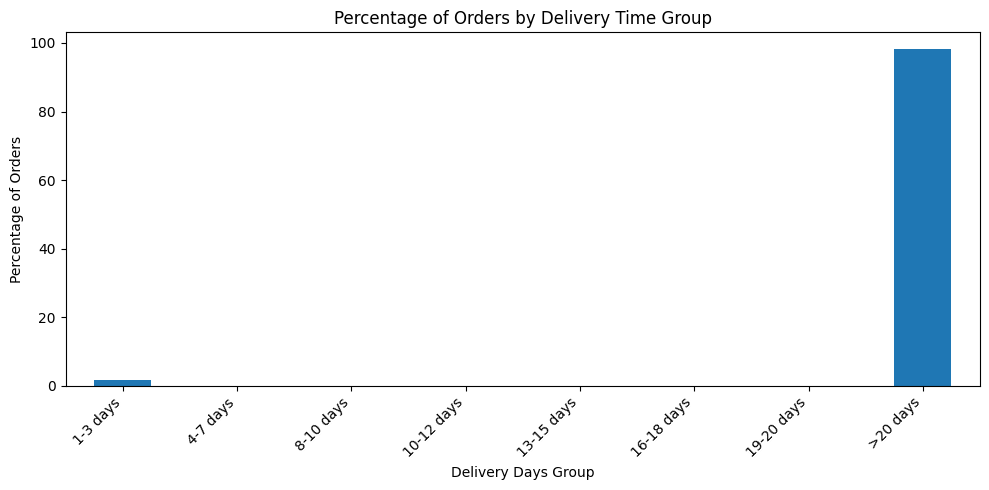

In [32]:
# Display delivery percentages in a bar chart
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
delivery_percentages.plot(kind="bar", ax=ax)
plt.xlabel("Delivery Days Group")
plt.ylabel("Percentage of Orders")
plt.title("Percentage of Orders by Delivery Time Group")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [50]:
# Redundant file upload - files should already be available.

In [49]:
# The 'orders' DataFrame is loaded and used consistently, this 'data' DataFrame is redundant and can cause conflicts.

In [34]:
# Payment Analysis
payments.groupby("payment_type")["payment_value"].sum()
payments.payment_value.describe()
payments.groupby("payment_installments")["payment_value"].mean()
payments.groupby("payment_installments")["payment_value"].mean()

,payment_value
payment_installments,
0,94.315000
1,112.420229
2,127.228150
3,142.539317
4,163.976840
5,183.465222
6,209.849952
7,187.673672
8,307.737427


# Generate a monthly dashboard that contains
| Month | Orders | Avg Days | SLA % | Revenue | Late % |
| ----- | ------ | -------- | ----- | ------- | ------ |


In [ ]:
#Exception Reports
Late_Deliveries.csv

Duplicate_Orders.csv

Orders_Without_Payment.csv

Negative_Payments.csv

In [51]:
# Export
orders_validation.to_csv(
    "Orders_Validation.csv",
    index=False
)

payment_validation.to_csv(
    "Payments_Validation.csv",
    index=False
)

# 'monthly' DataFrame is not yet defined, so this line will cause an error.
# monthly.to_csv(
#     "Monthly_KPI_Report.csv"
# )